# Unconditional Cavity Displacement in Dispersive cQED - Reproducibility Notebook

This notebook reproduces the main results of the unconditional-displacement study by loading the saved `unconditional_*` artifacts and, if requested, re-running the study scripts.

The workflow is intentionally split into:

1. environment and configuration
2. optional end-to-end rerun
3. artifact loading and headline summaries
4. figure review
5. validation spot checks
6. optimal-control waveform inspection

The main scientific takeaway is that the short `20 ns` two-tone branch-compensated pulse is the best tested protocol on the explicit broad state set, while the constrained `40 ns` optimal-control waveform remains the strongest bounded sampled-waveform reference and the structured multiplex follow-up remains a negative result.


In [1]:
import sys
from pathlib import Path

cwd = Path.cwd()
candidates = [
    cwd,
    cwd / "studies" / "waveform_level_gate_realization_dispersive_cqed" / "scripts",
]
SCRIPT_DIR = next((path for path in candidates if (path / "common.py").exists()), None)
if SCRIPT_DIR is None:
    raise FileNotFoundError("Could not locate the study scripts directory from the current working directory.")

STUDY_DIR = SCRIPT_DIR.parent
ARTIFACTS_DIR = STUDY_DIR / "artifacts"
FIGURES_DIR = STUDY_DIR / "figures"
REPORT_DIR = STUDY_DIR / "report"
REPO_ROOT = STUDY_DIR.parent.parent
CQED_SIM_ROOT = REPO_ROOT.parent / "cQED_simulation"

if str(SCRIPT_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPT_DIR))
if str(CQED_SIM_ROOT) not in sys.path:
    sys.path.insert(0, str(CQED_SIM_ROOT))

import common
common.apply_plot_style()

print(f"Study directory: {STUDY_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"Figures directory: {FIGURES_DIR}")
print(f"Report directory: {REPORT_DIR}")


Study directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\waveform_level_gate_realization_dispersive_cqed
Artifacts directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\waveform_level_gate_realization_dispersive_cqed\artifacts
Figures directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\waveform_level_gate_realization_dispersive_cqed\figures
Report directory: c:\Users\jl82323\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cqed_based_study\studies\waveform_level_gate_realization_dispersive_cqed\report


## Tunable Parameters

All tunable parameters used by the notebook live in the next cell. The defaults mirror the saved study configuration. Set the rerun flags to `True` if you want to regenerate the artifacts instead of loading the existing ones.


In [2]:
# Study-scale knobs
N_TR = 3
N_CAV = 15
OPTIMAL_N_CAV = 12
DEFAULT_DT_NS = 0.5

# Physical parameters
CHI_MHZ = -2.84
CHI_PRIME_KHZ = -21.0
KERR_KHZ = -28.0

# Sweep grids
ALPHA_TARGETS = [0.5, 1.0, 1.5, 2.0]
SINGLE_TONE_DURATIONS_NS = [5.0, 10.0, 20.0, 40.0, 80.0, 160.0]
ECHO_TOTAL_DURATIONS_NS = [60.0, 80.0, 120.0, 160.0]
OPTIMAL_DURATIONS_NS = [40.0, 80.0]
CHI_SCALE_FACTORS = [0.5, 1.0, 1.5, 2.0]

# Validation states
QUBIT_STATES = ["g", "e", "plus_x", "plus_y"]
CAVITY_STATES = ["vacuum", "fock1", "fock2", "fock3", "coherent"]

# Notebook control flags
RERUN_MAIN_DRIVER = False
RERUN_VALIDATION = False
RERUN_OPTIMAL_WAVEFORM_PLOT = False
RERUN_MULTIPLEX_FOLLOWUP = False

print("Configuration loaded.")
print(f"n_tr={N_TR}, n_cav={N_CAV}, optimal_n_cav={OPTIMAL_N_CAV}, dt={DEFAULT_DT_NS} ns")
print(f"chi/2pi={CHI_MHZ} MHz, chi'/2pi={CHI_PRIME_KHZ} kHz, K/2pi={KERR_KHZ} kHz")


Configuration loaded.
n_tr=3, n_cav=15, optimal_n_cav=12, dt=0.5 ns
chi/2pi=-2.84 MHz, chi'/2pi=-21.0 kHz, K/2pi=-28.0 kHz


## Optional End-to-End Rerun

Turn on any of the rerun flags in the configuration cell and execute the next cell if you want to regenerate artifacts or figures. The default path is load-only so the notebook stays lightweight.


In [3]:
if RERUN_MAIN_DRIVER:
    import unconditional_displacement_study
    unconditional_displacement_study.main()

if RERUN_VALIDATION:
    import unconditional_validation
    unconditional_validation.main()

if RERUN_OPTIMAL_WAVEFORM_PLOT:
    import plot_unconditional_optimal_waveform
    plot_unconditional_optimal_waveform.main()

if RERUN_MULTIPLEX_FOLLOWUP:
    import multiplex_displacement_followup
    multiplex_displacement_followup.main()

print("Optional rerun cell finished.")


Optional rerun cell finished.


## Load Saved Artifacts

The helper `common.load_json` returns the artifact payload directly, so the notebook can work with the saved JSON without extra schema handling.


In [4]:
summary = common.load_json(ARTIFACTS_DIR / "unconditional_displacement_summary.json")
protocols = common.load_json(ARTIFACTS_DIR / "unconditional_protocol_comparison.json")
single_tone = common.load_json(ARTIFACTS_DIR / "unconditional_single_tone_summary.json")
two_tone = common.load_json(ARTIFACTS_DIR / "unconditional_two_tone_summary.json")
echo_data = common.load_json(ARTIFACTS_DIR / "unconditional_echo_summary.json")
optimal = common.load_json(ARTIFACTS_DIR / "unconditional_optimal_control_summary.json")
multiplex_followup = common.load_json(ARTIFACTS_DIR / "unconditional_multiplex_followup.json")
validation = common.load_json(ARTIFACTS_DIR / "unconditional_validation_spotcheck.json")

print("Loaded unconditional-displacement artifacts:")
for name in [
    "unconditional_displacement_summary.json",
    "unconditional_protocol_comparison.json",
    "unconditional_single_tone_summary.json",
    "unconditional_two_tone_summary.json",
    "unconditional_echo_summary.json",
    "unconditional_optimal_control_summary.json",
    "unconditional_multiplex_followup.json",
    "unconditional_validation_spotcheck.json",
]:
    print(" -", name)


Loaded unconditional-displacement artifacts:
 - unconditional_displacement_summary.json
 - unconditional_protocol_comparison.json
 - unconditional_single_tone_summary.json
 - unconditional_two_tone_summary.json
 - unconditional_echo_summary.json
 - unconditional_optimal_control_summary.json
 - unconditional_multiplex_followup.json
 - unconditional_validation_spotcheck.json


## Headline Numerical Results

This cell prints the main benchmark points used throughout the report.


In [5]:
baseline = summary["baseline_square_80ns"]
fast = summary["best_fast_gaussian"]
twotone_best = summary["best_two_tone"]
echo_best = summary["best_echo"]
optimal_best = summary["best_optimal"]
followup_summary = multiplex_followup["summary"]

print("Baseline naive square (80 ns, alpha=1):")
print(f"  delta_alpha = {baseline['delta_alpha']:.6f}")
print(f"  F_g = {baseline['g_fidelity']:.6f}, F_e = {baseline['e_fidelity']:.6f}, F_+x = {baseline['plus_x_fidelity']:.6f}")
print(f"  entanglement = {baseline['plus_x_entanglement_bits']:.6f} bits")

print("\nBest fast Gaussian:")
print(f"  duration = {fast['duration_ns']:.1f} ns, bandwidth = {fast['bandwidth_mhz']:.1f} MHz")
print(f"  delta_alpha = {fast['delta_alpha']:.6f}, F_+x = {fast['plus_x_fidelity']:.6f}")

print("\nBest two-tone:")
print(f"  duration = {twotone_best['duration_ns']:.1f} ns")
print(f"  delta_alpha = {twotone_best['delta_alpha']:.6e}, F_+x = {twotone_best['plus_x_fidelity']:.6f}")
print(f"  broad-set mean fidelity = {followup_summary['two_tone_20_mean_fidelity']:.6f}")

print("\nBest echoed case:")
print(f"  total duration = {echo_best['total_duration_ns']:.1f} ns")
print(f"  delta_alpha = {echo_best['delta_alpha']:.6f}, F_+x = {echo_best['plus_x_fidelity']:.6f}")

print("\nBest constrained optimal-control case:")
print(f"  duration = {optimal_best['duration_ns']:.1f} ns")
print(f"  mean state fidelity = {optimal_best['full_metrics']['state_test_mean_fidelity']:.6f}")
print(f"  minimum state fidelity = {optimal_best['full_metrics']['state_test_min_fidelity']:.6f}")
print(f"  vacuum delta_alpha = {optimal_best['vacuum_metrics']['delta_alpha']:.6f}")

print("\nStructured multiplex follow-up:")
print(f"  best full-duration multiplex mean fidelity = {followup_summary['best_multiplex_mean_fidelity']:.6f}")
print(f"  best segmented multiplex mean fidelity = {followup_summary['best_segmented_mean_fidelity']:.6f}")
print(f"  joint-shaped two-tone mean fidelity = {followup_summary['joint_shaped_two_tone_mean_fidelity']:.6f}")


Baseline naive square (80 ns, alpha=1):
  delta_alpha = 0.685870
  F_g = 0.999960, F_e = 0.622737, F_+x = 0.770319
  entanglement = 0.482920 bits

Best fast Gaussian:
  duration = 5.0 ns, bandwidth = 200.0 MHz
  delta_alpha = 0.053911, F_+x = 0.997743

Best two-tone:
  duration = 20.0 ns
  delta_alpha = 8.154259e-04, F_+x = 0.997680
  broad-set mean fidelity = 0.985722

Best echoed case:
  total duration = 60.0 ns
  delta_alpha = 0.078728, F_+x = 0.891358

Best constrained optimal-control case:
  duration = 40.0 ns
  mean state fidelity = 0.957535
  minimum state fidelity = 0.874808
  vacuum delta_alpha = 0.104776

Structured multiplex follow-up:
  best full-duration multiplex mean fidelity = 0.524154
  best segmented multiplex mean fidelity = 0.361232
  joint-shaped two-tone mean fidelity = 0.157618


## Protocol Ranking Table

The next cell shows the common state-test-set ranking used in the report.


In [ ]:
rows = []
for item in protocols["protocols"]:
    rows.append({
        "label": item["label"],
        "duration_ns": item["duration_ns"],
        "mean_fidelity": round(item["full_metrics"]["state_test_mean_fidelity"], 6),
        "min_fidelity": round(item["full_metrics"]["state_test_min_fidelity"], 6),
        "vacuum_delta_alpha": round(item["vacuum_metrics"]["delta_alpha"], 6),
        "vacuum_plus_x_fidelity": round(item["vacuum_metrics"]["plus_x_fidelity"], 6),
        "vacuum_plus_x_ent_bits": round(item["vacuum_metrics"]["plus_x_entanglement_bits"], 6),
        "complexity": item["complexity"],
    })

rows


## Figure Review

The report relies on the saved figure files. Displaying them here makes it easy to inspect the branch mismatch, entanglement, filter tradeoff, protocol summary, Wigner comparison, and optimal waveform directly from the notebook.


Displaying unconditional_branch_mismatch.png


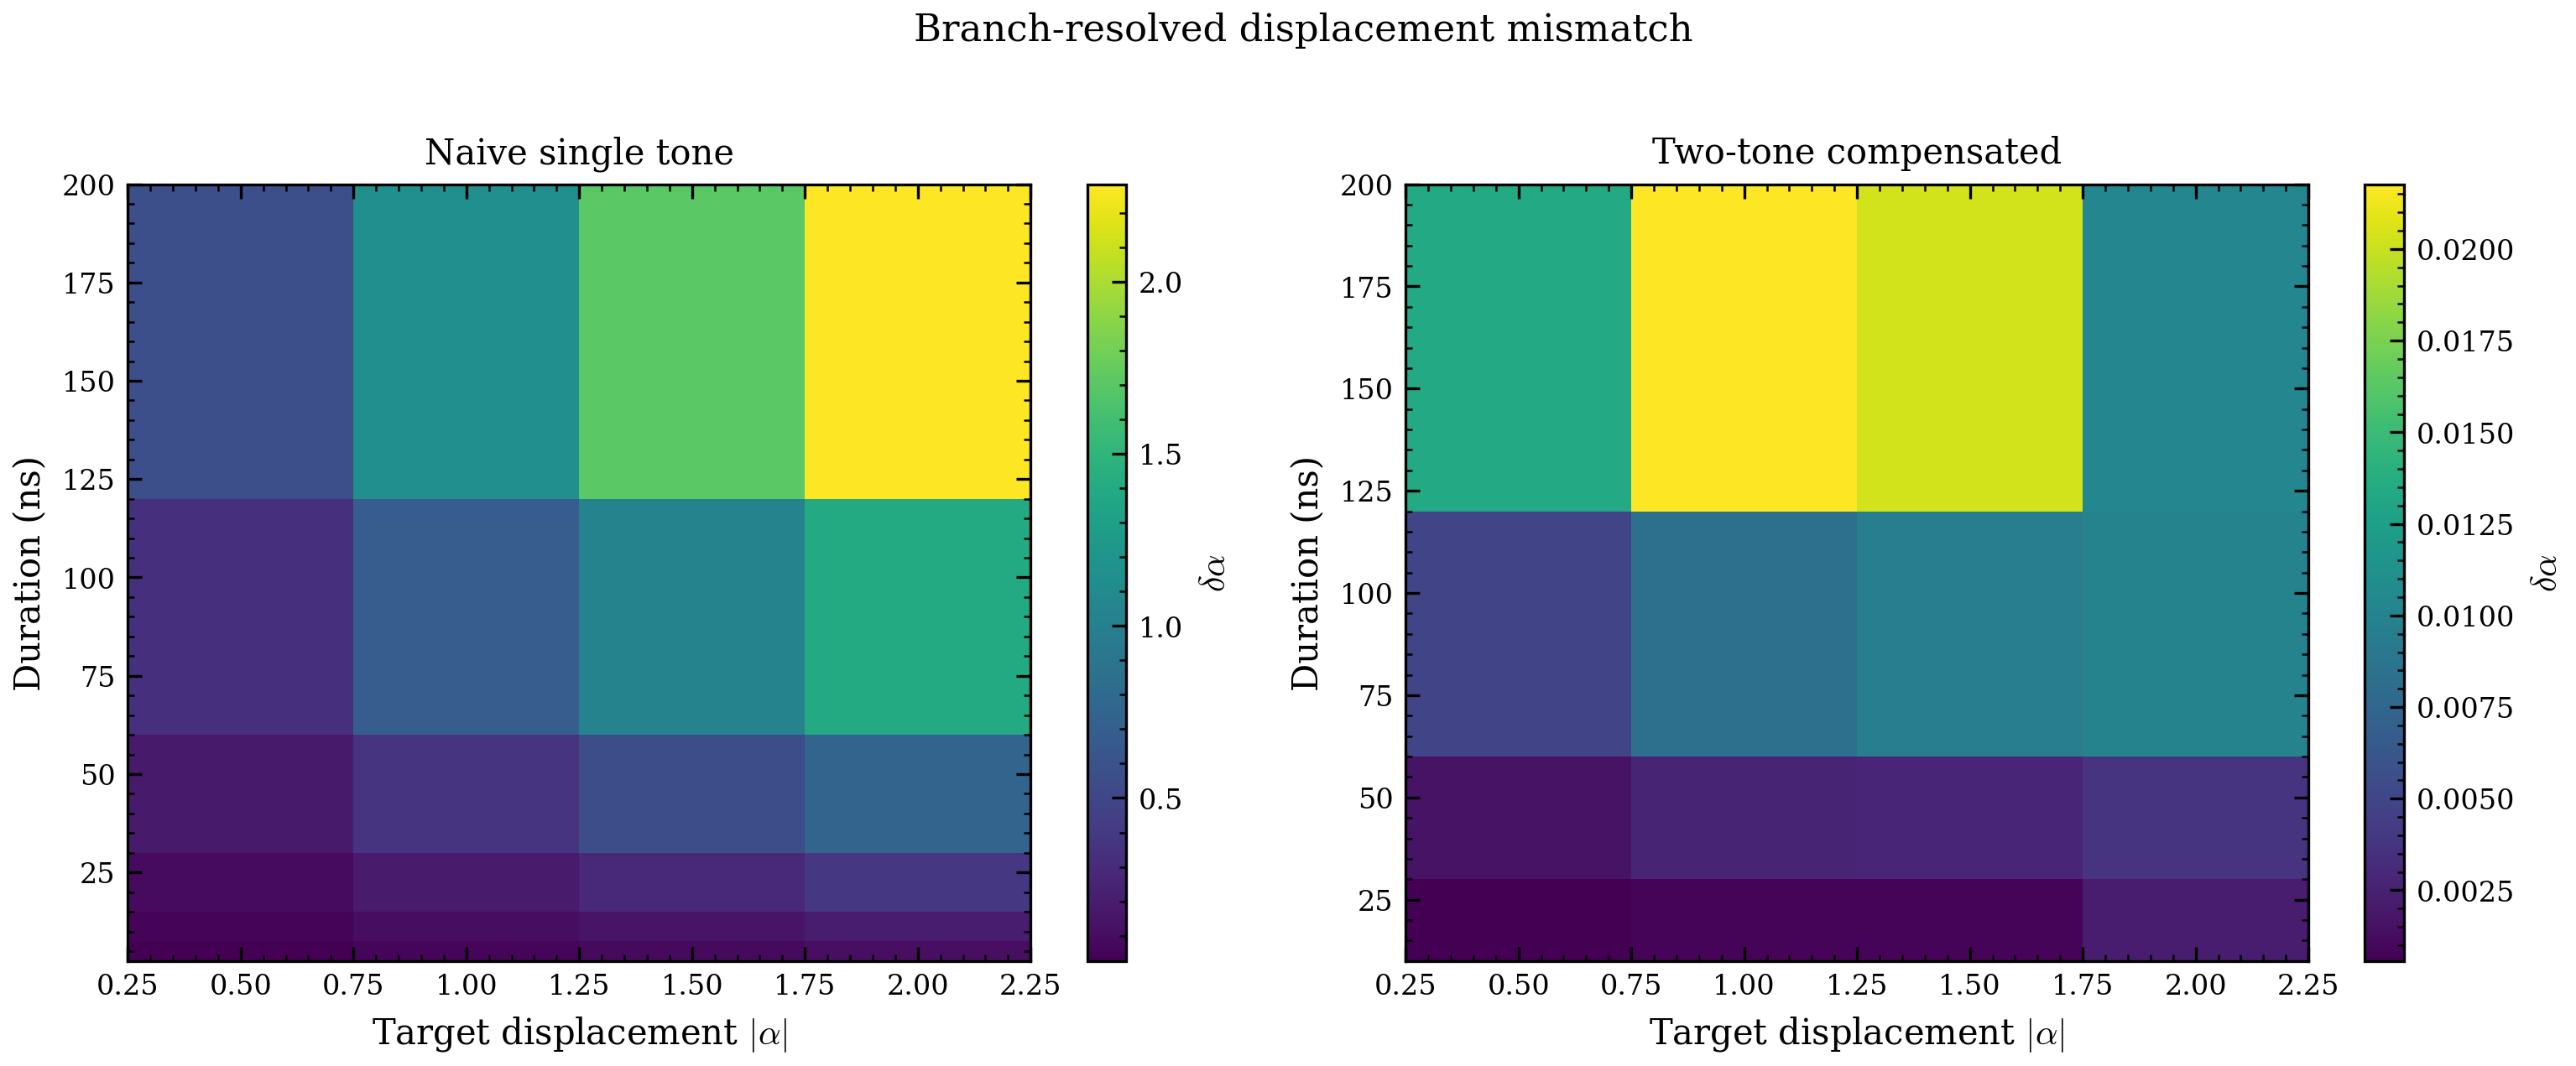

Displaying unconditional_superposition_entanglement.png


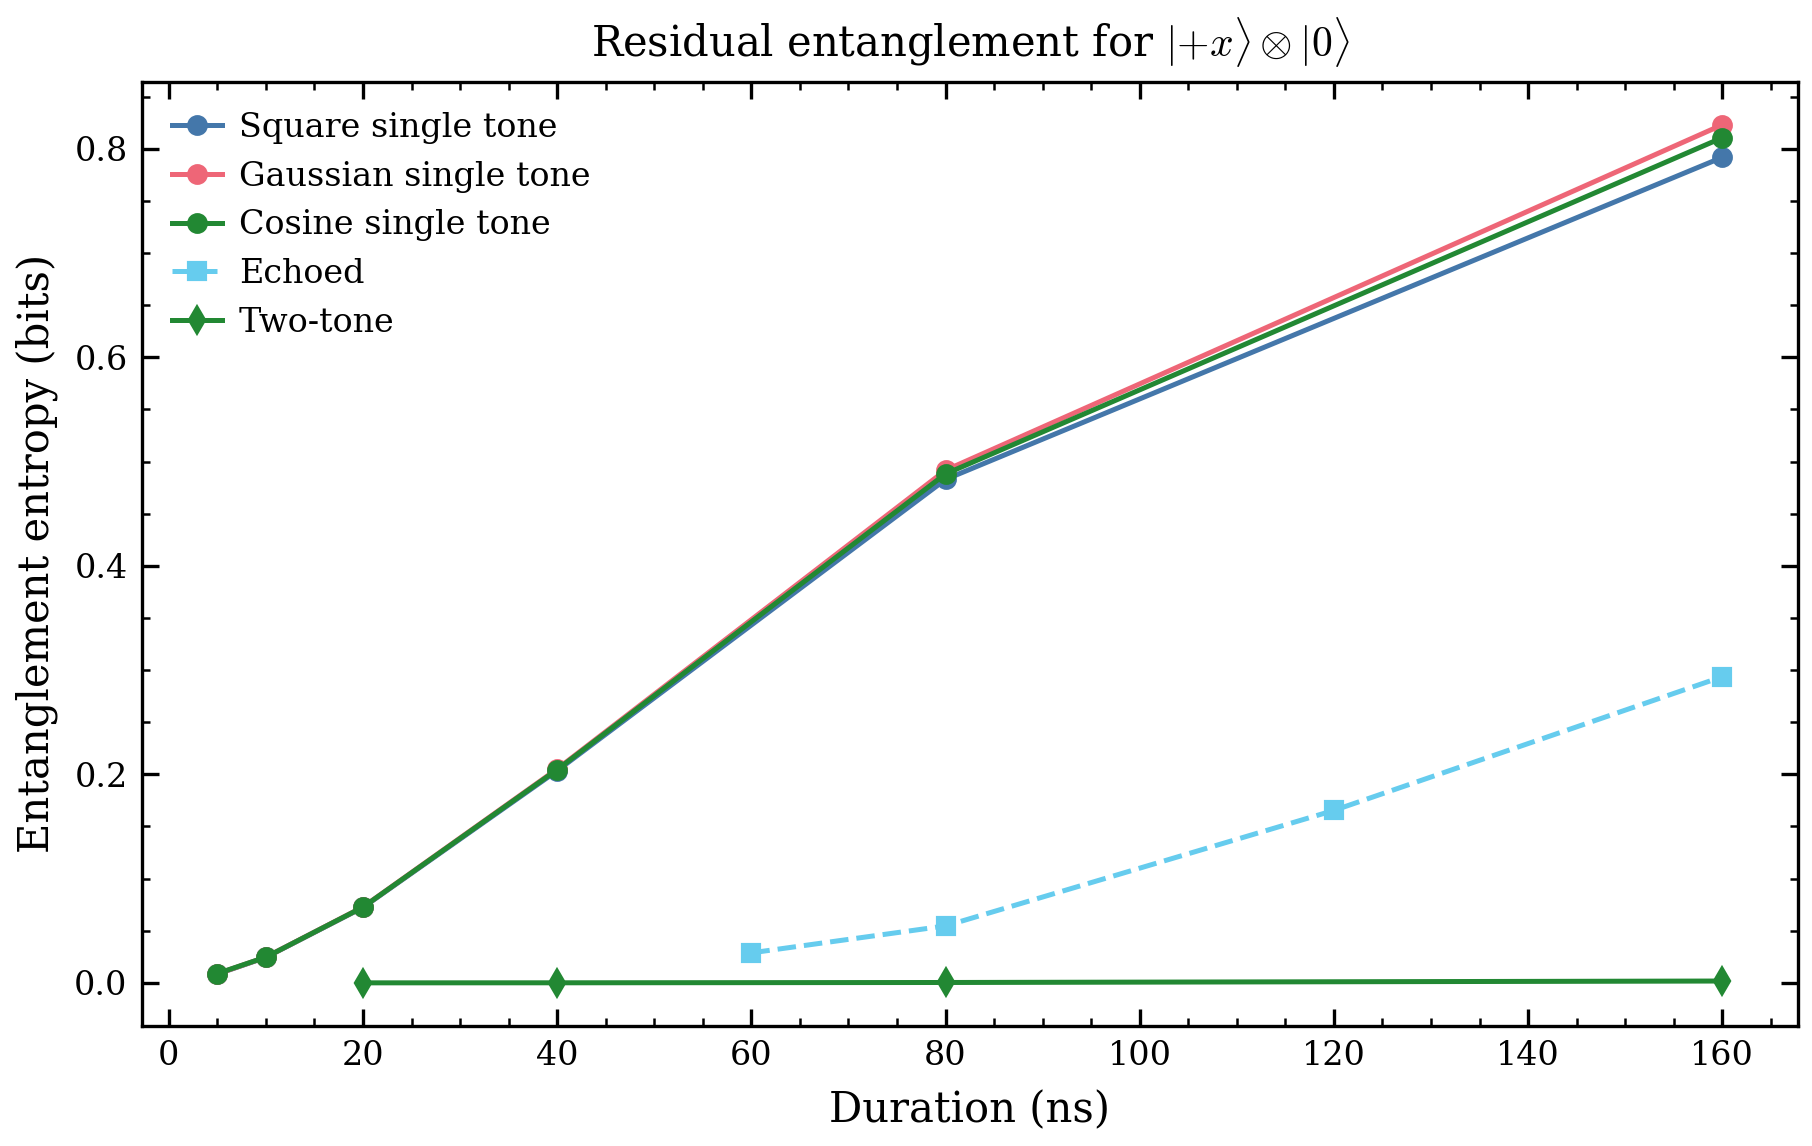

Displaying unconditional_filter_tradeoff.png


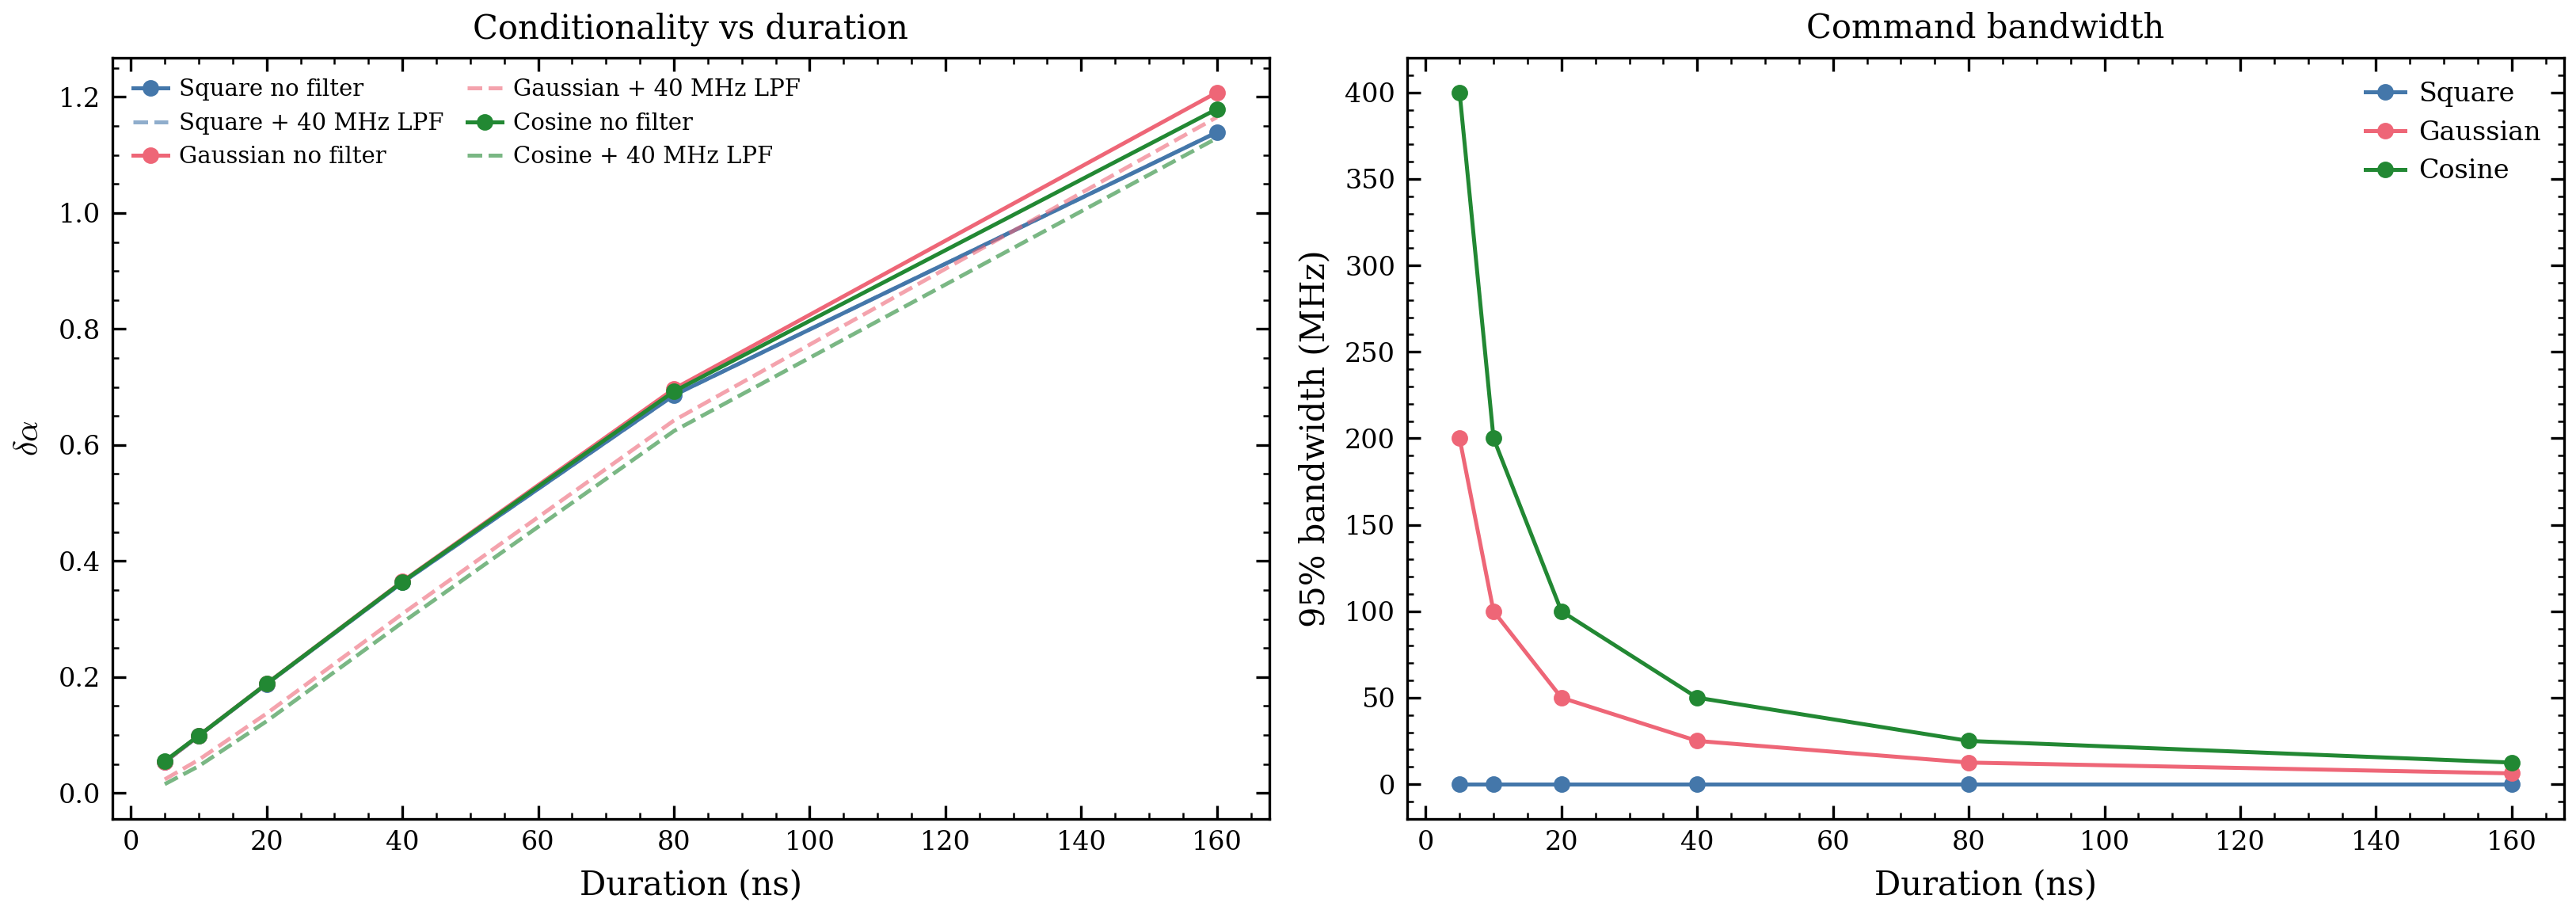

Displaying unconditional_protocol_summary.png


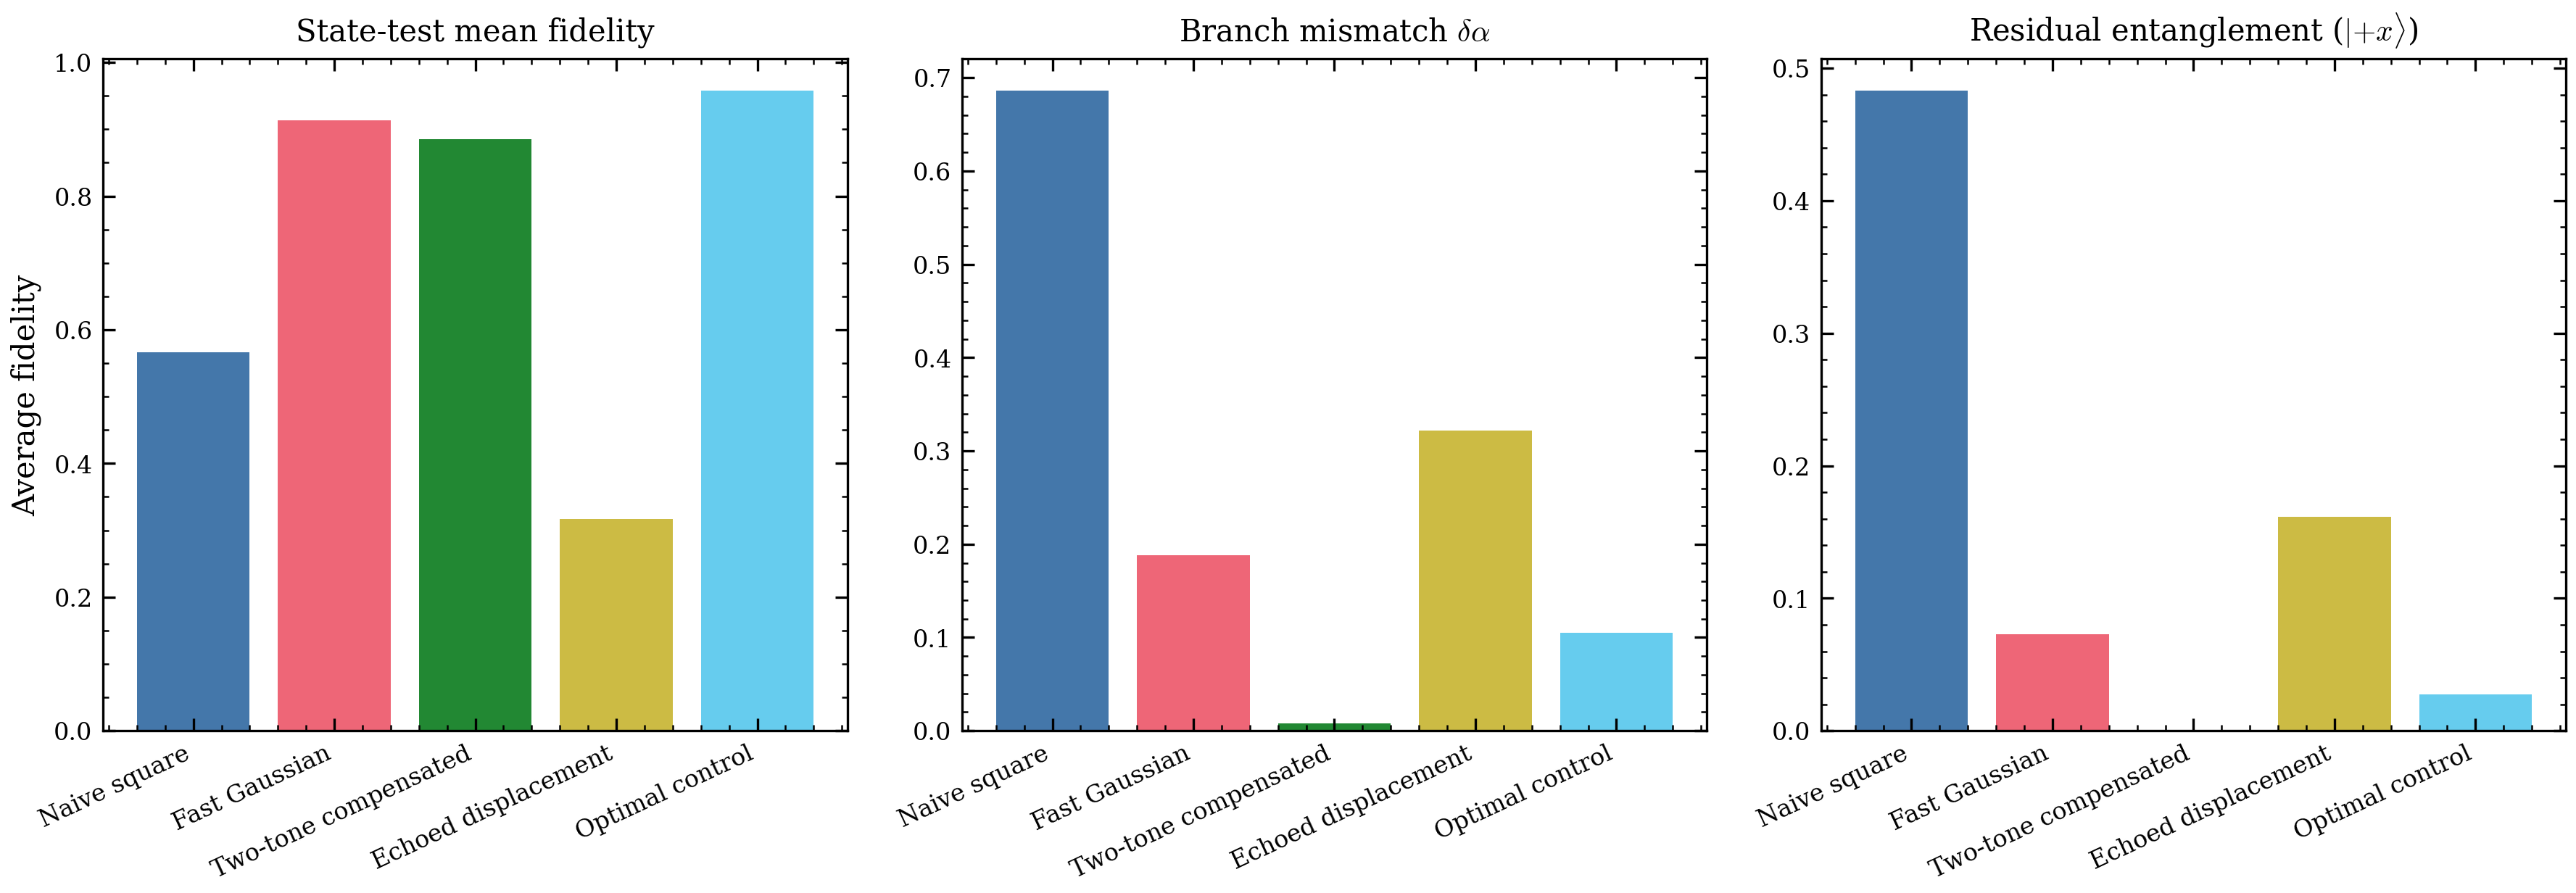

Displaying unconditional_wigner_comparison.png


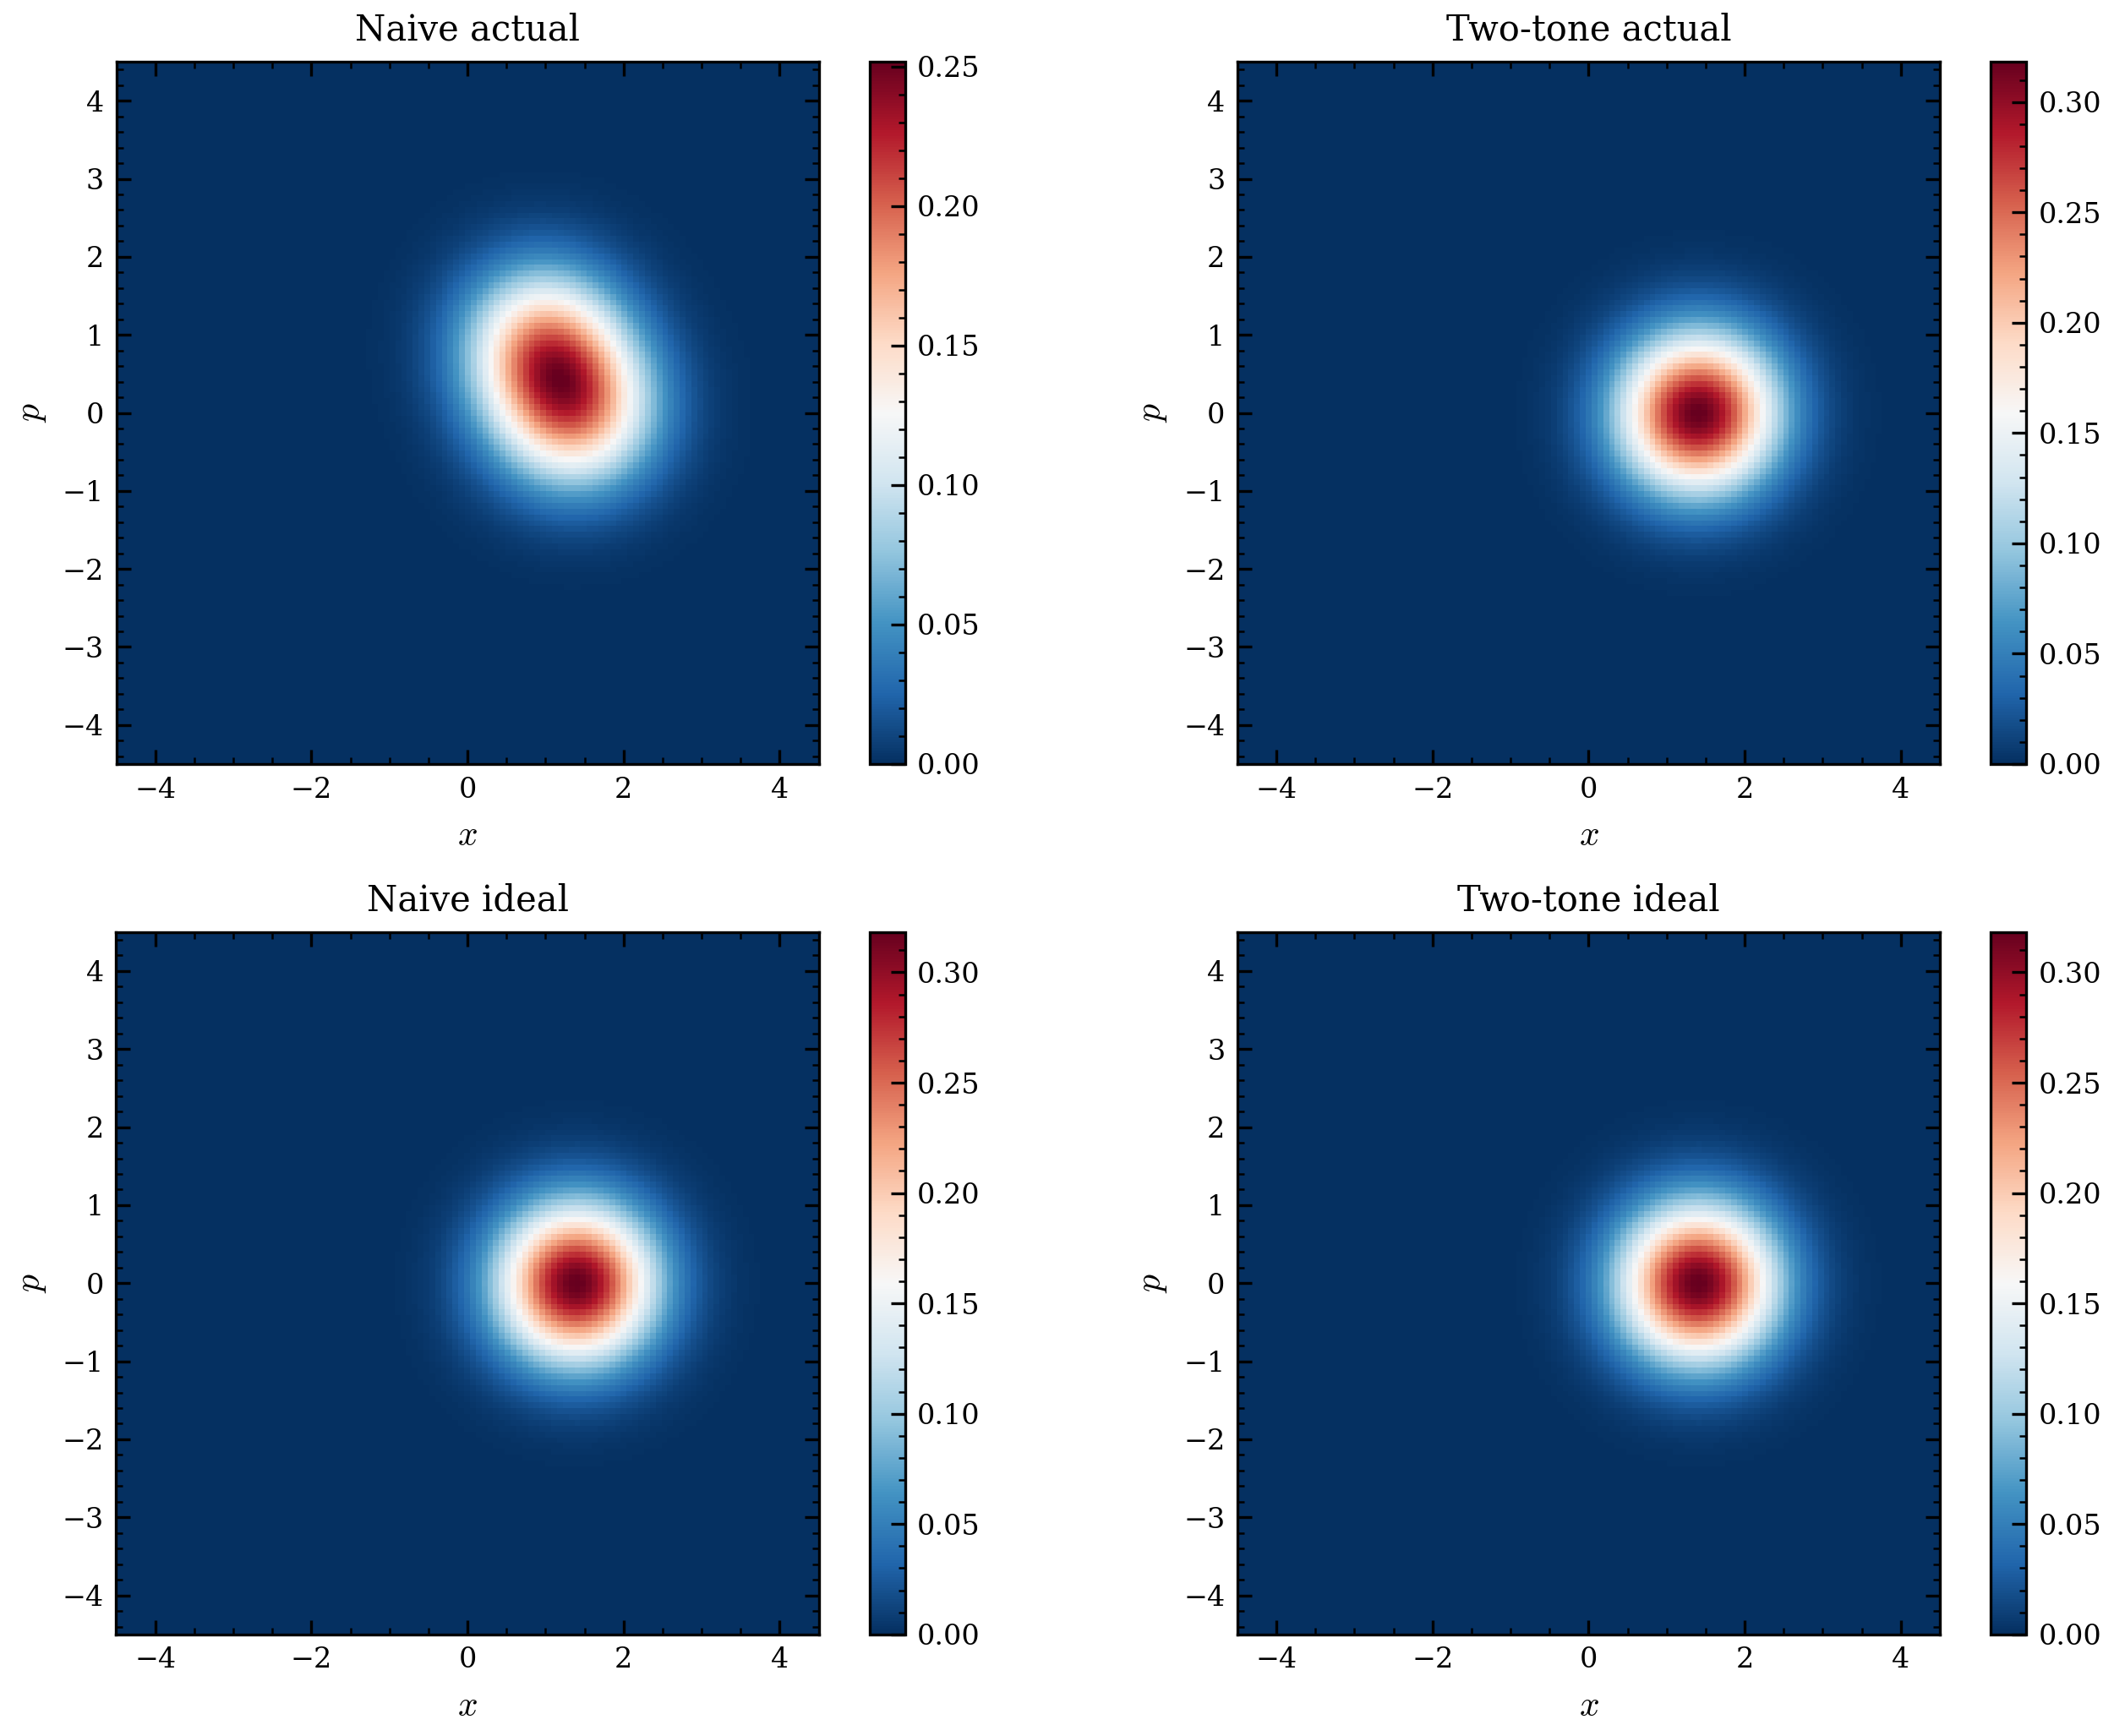

Displaying unconditional_optimal_waveform.png


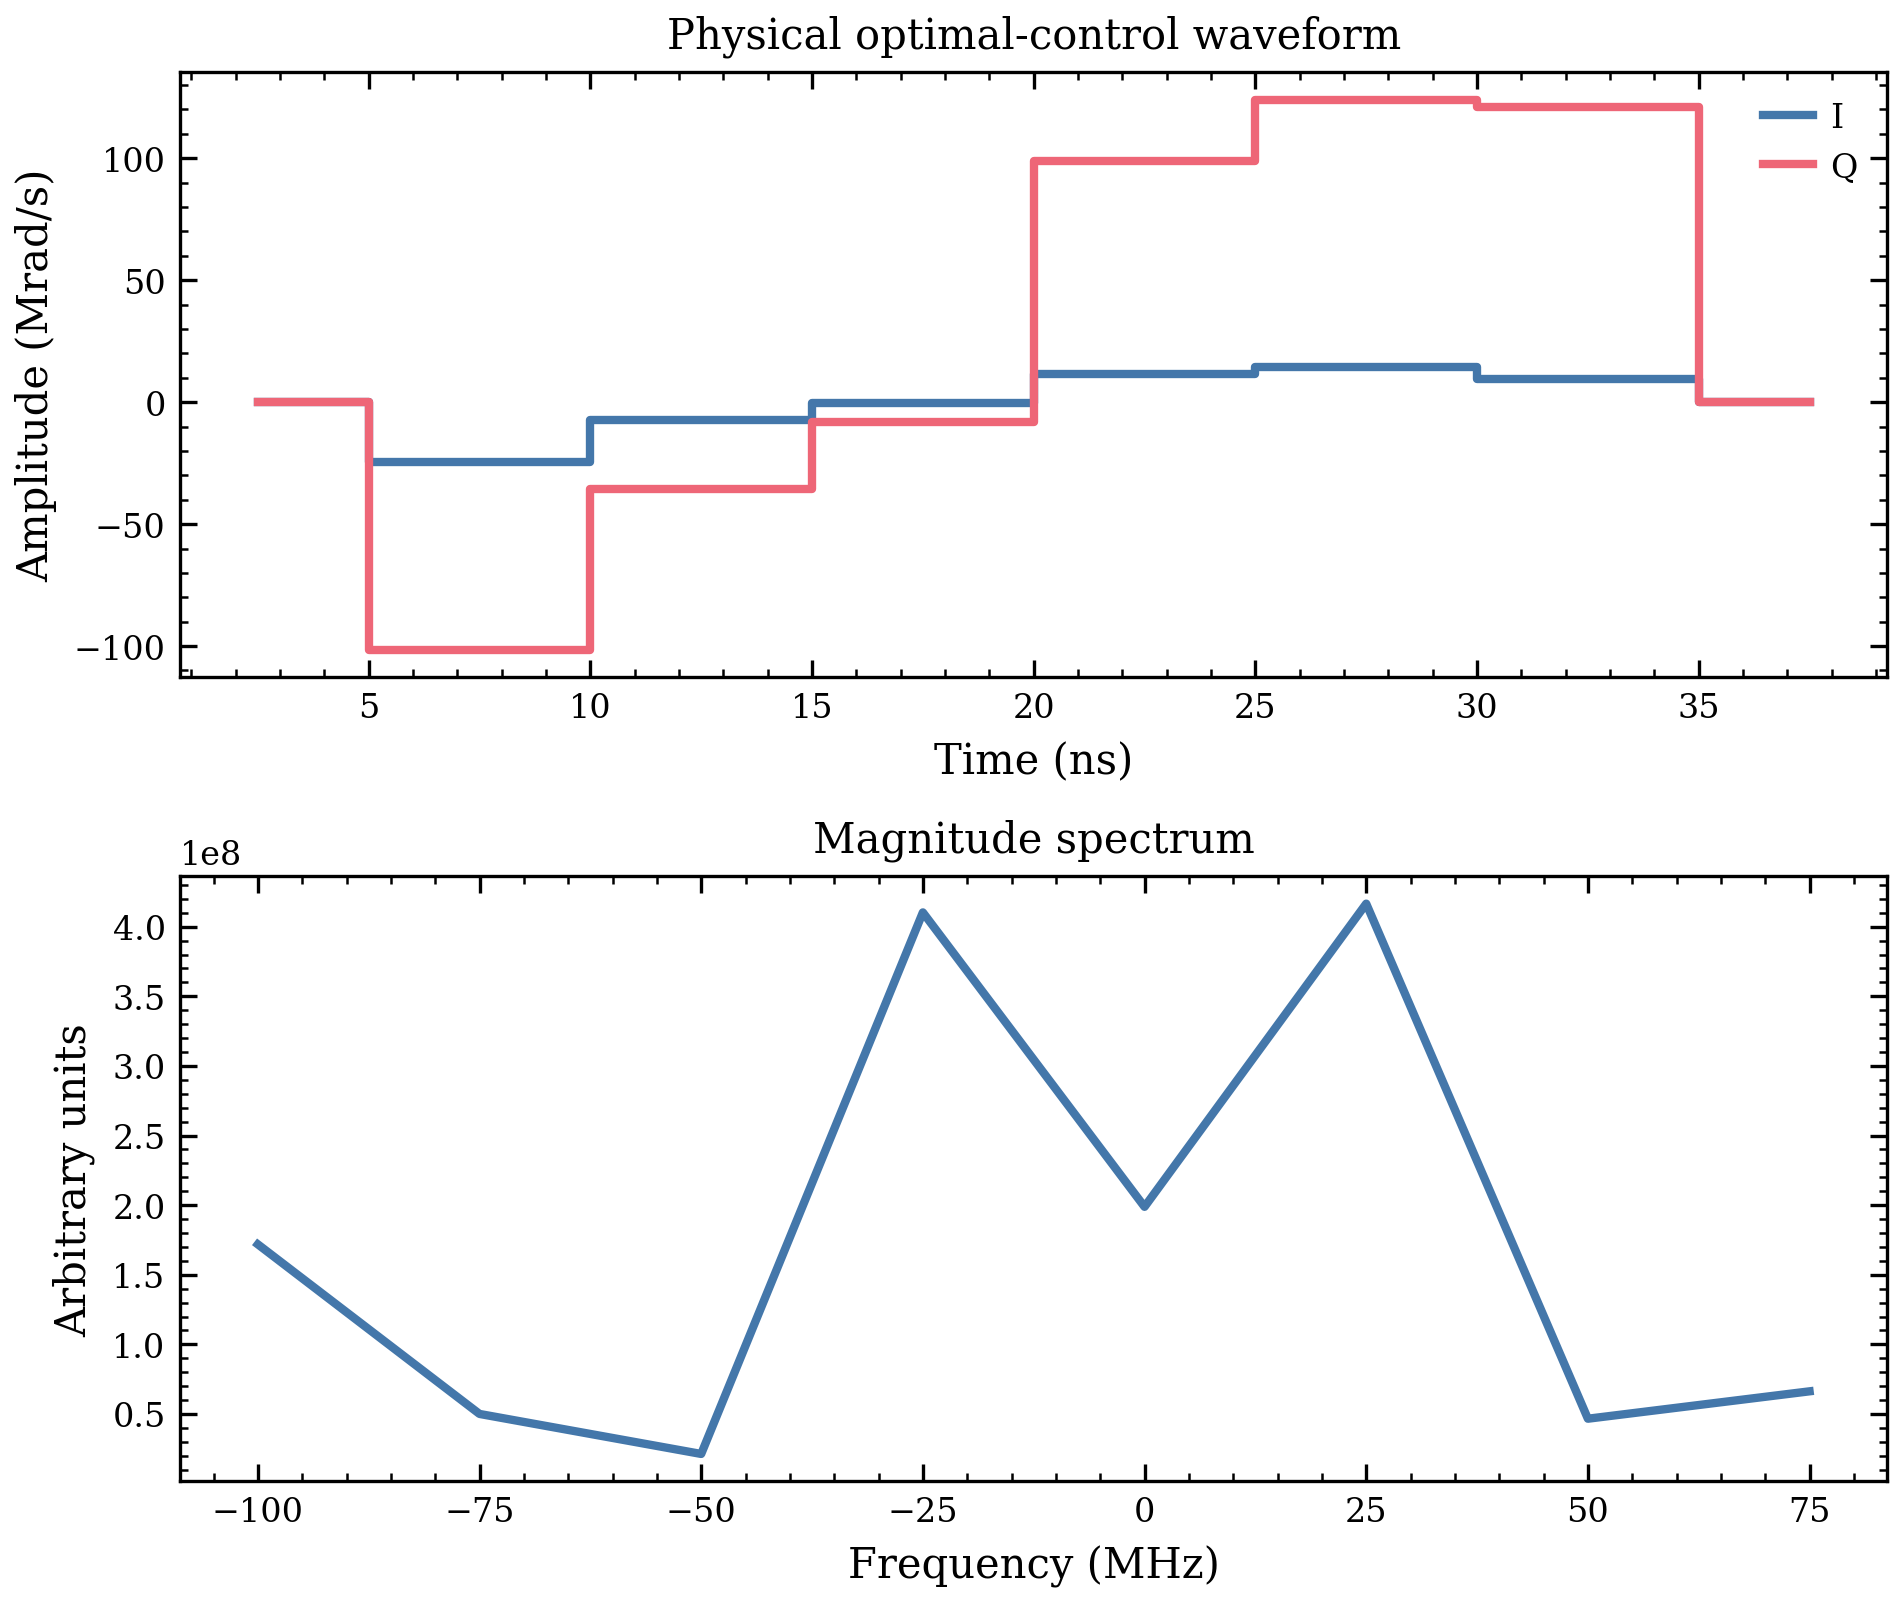

Displaying unconditional_multiplex_followup.png


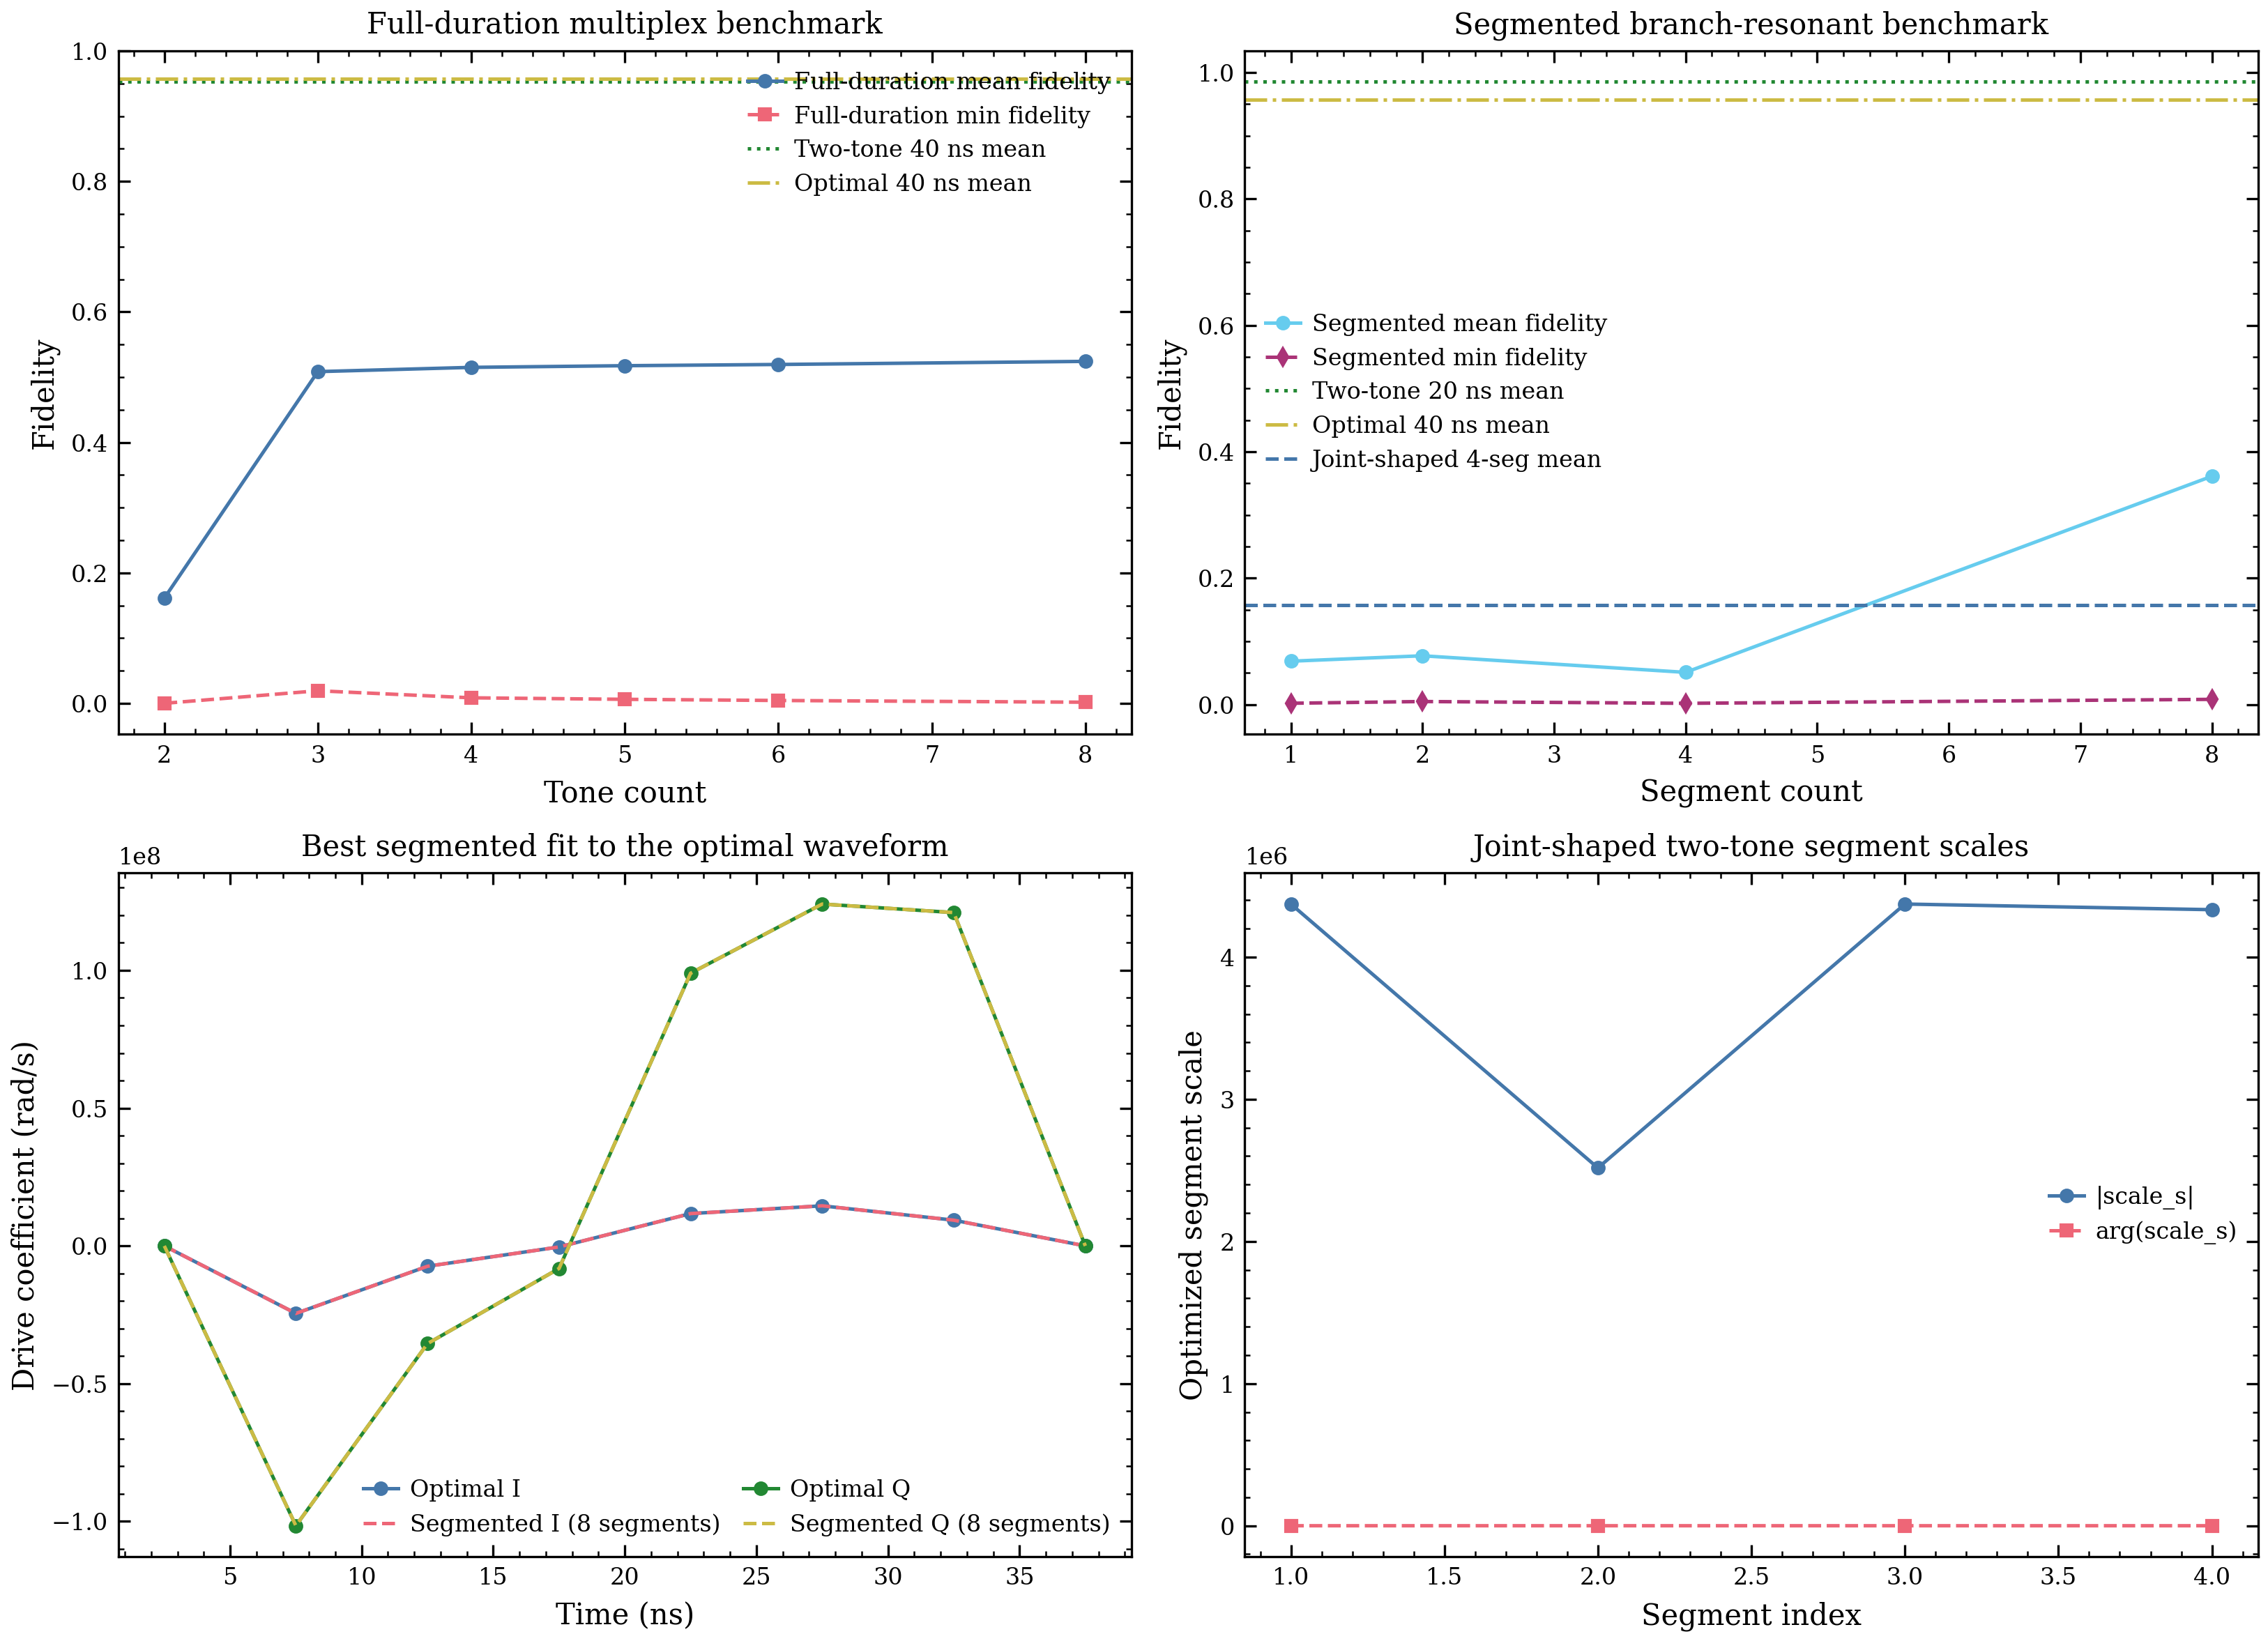

In [6]:
from IPython.display import Image, display

for name in [
    "unconditional_branch_mismatch.png",
    "unconditional_superposition_entanglement.png",
    "unconditional_filter_tradeoff.png",
    "unconditional_protocol_summary.png",
    "unconditional_wigner_comparison.png",
    "unconditional_optimal_waveform.png",
    "unconditional_multiplex_followup.png",
]:
    path = FIGURES_DIR / name
    print(f"Displaying {name}")
    display(Image(filename=str(path)))


## Validation Spot Checks

The study includes a direct unconditional-displacement validation artifact in addition to the broader shared-model convergence evidence from the earlier waveform-level study.


In [ ]:
print("Ideal limit:")
ideal = validation["ideal_limit"]
print(f"  delta_alpha = {ideal['delta_alpha']:.6e}")
print(f"  F_+x = {ideal['plus_x_fidelity']:.6f}")

print("\nn_cav sweep:")
for row in validation["n_cav_sweep"]:
    print(f"  n_cav={row['n_cav']}: delta_alpha={row['delta_alpha']:.6f}, F_+x={row['plus_x_fidelity']:.6f}")

print("\ndt sweep:")
for row in validation["dt_sweep"]:
    print(f"  dt={row['dt_ns']:.2f} ns: delta_alpha={row['delta_alpha']:.6f}, F_+x={row['plus_x_fidelity']:.6f}")

print("\nn_tr sweep:")
for row in validation["n_tr_sweep"]:
    print(f"  n_tr={row['n_tr']}: delta_alpha={row['delta_alpha']:.6f}, F_+x={row['plus_x_fidelity']:.6f}")


## Optimal-Control Waveform Details

The next cell exposes the actual optimized schedule used in the appendix, together with the main hardware metrics. This keeps the optimization result transparent rather than treating it as a black box.


In [ ]:
best_case = max(optimal["cases"], key=lambda item: item["full_metrics"]["state_test_mean_fidelity"])
schedule = best_case["schedule_values"]
hardware = best_case["hardware_metrics"]

print("Held-sample schedule values (rad/s):")
print(schedule)

print("\nHardware metrics:")
for key in [
    "physical_max_abs_amplitude",
    "physical_rms_amplitude",
    "physical_max_slew",
    "hardware_map_count",
]:
    print(f"  {key}: {hardware[key]}")


## Final Interpretation

The saved data support four practical conclusions:

1. a long naive cavity pulse should not be modeled as unconditional in this dispersive regime,
2. the short `20 ns` two-tone branch-compensated pulse is the best tested protocol on the explicit broad state set as well as the best simple experimental strategy,
3. the constrained `40 ns` optimal-control waveform remains the strongest bounded sampled-waveform reference,
4. explicit full-duration multicarrier fits, segmented branch-resonant fits, and a low-parameter jointly optimized shaped-two-tone family all remain negative structured-multiplex results.

If you change the configuration or rerun flags above, re-execute the notebook from the configuration cell onward so the plots and summaries stay consistent with the modified workflow.
